## **SIN 393 – Introduction to Computer Vision (2026)**

### Prof. João Fernando Mari ([*joaofmari.github.io*](https://joaofmari.github.io/))

Copyright (c) 2026 João Fernando Mari.  
Licensed under the MIT License.

---

# Lecture 2 - Notebook 2 - Bayes Classifier
---

## Importing the Required Libraries
---

In [1]:
import numpy as np

from scipy import spatial, stats
from sklearn import datasets, model_selection, preprocessing, neighbors, metrics, svm, naive_bayes

import matplotlib.pylab as plt
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable

import pandas as pd
import seaborn as sns

%matplotlib inline

## Preparing the Iris Dataset
---

* We will use a very well-known dataset, the **Iris dataset**.

* 3 classes:
    * Iris Setosa;
    * Iris Versicolor;
    * Iris Virginica.

* 150 samples:
    * 50 samples from each class.

* 4 features:
    * Sepal length;
    * Sepal width;
    * Petal length;
    * Petal width.

<img src='figuras/iris_dataset_ok.png' style="height:300px"><img>

*https://en.wikipedia.org/wiki/Iris_flower_data_set*

* References:
    * https://en.wikipedia.org/wiki/Iris_flower_data_set
    * R. A. Fisher (1936). "The use of multiple measurements in taxonomic problems." *Annals of Eugenics*, 7(2): 179–188.
    * http://scikit-learn.org/stable/auto_examples/datasets/plot_iris_dataset.html

In [2]:
# Load the Iris dataset
iris = datasets.load_iris()

# Data
X = iris.data

# Labels
y = iris.target

In [3]:
# Number of samples
num_objs = X.shape[0]
# Number of features
num_feat = X.shape[1]
# Number of classes
num_classes = len(np.unique(y))
# Feature names
feat_names = iris.feature_names
# Class names
class_names = list(iris.target_names)

In [4]:
print(f'Number of samples: {num_objs}')
print(f'Number of features: {num_feat}')
print(f'Features: {str(feat_names)[1:-1]}')
print(f'Number of classes: {num_classes}')
print(f'Classes: {str(class_names)[1:-1]}')

Number of samples: 150
Number of features: 4
Features: 'sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'
Number of classes: 3
Classes: np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')


### Visualizing the Iris Dataset

In [5]:
df = pd.DataFrame(X, columns=feat_names)
df['class'] = y

pd.set_option('display.expand_frame_repr', False)
display(df)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


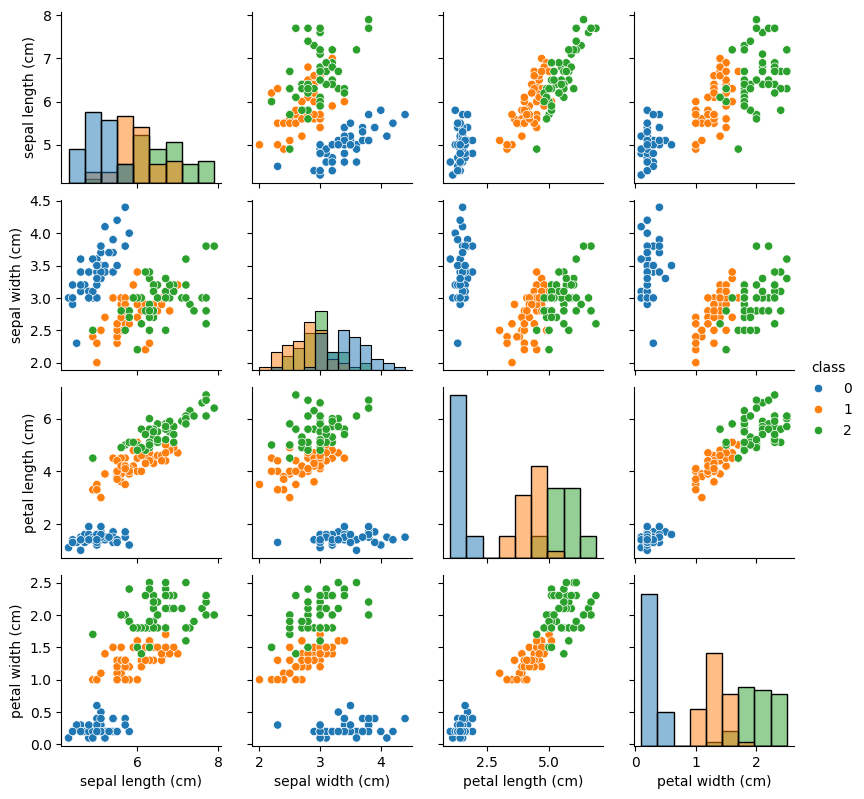

In [6]:
g = sns.PairGrid(df, hue='class', vars=feat_names, palette='tab10')
g.fig.set_size_inches(8, 8)
g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot)
g.add_legend()

### Preparing the Dataset

In [7]:
# Select only 2 classes:
# - Setosa (0) and Virginica (2).
mask = (iris.target == 0) | (iris.target == 2)

X_ = iris.data[mask]
y_ = iris.target[mask].copy()

class_names_ = [class_names[0], class_names[2]]

# Adjust the class labels to [0, 1]
y_[y_ == 2] = 1

# Select only 1 feature:
# Sepal length (0)
X_ = X_[:, 0]

# Keep the dataset 2D
X_ = X_[:, np.newaxis]

In [8]:
# Split the dataset into training (70%) and test (30%) sets
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X_,
    y_,
    test_size=0.3,
    random_state=42
)

### Normalizing the Features

In [9]:
# Create the standardization object
scaler = preprocessing.StandardScaler()

# Compute the mean and standard deviation using only the training set
scaler.fit(X_train)

# Standardize the training set
X_train_norm = scaler.transform(X_train)
# Standardize the test set using the training set statistics
X_test_norm = scaler.transform(X_test)

## Bayes Classifier
----


$$
G(h) = \frac{1}{\sqrt{2\pi\sigma^2}}e^-\frac{(h-\mu)^2}{2\sigma^2}
$$
        

In [10]:
class SimpleBayes:
    """
    Simple implementation of a Bayesian classifier for two classes, C0 and C1, using a single observed feature h.

    The class-conditional probability density of each class is modeled  using a Gaussian distribution.

    Reference
    ---------
    [1] COSTA & CESAR-JR. Shape analysis and classification: theory and practice. CRC Press, 2000.
        Section 8.2: Supervised Pattern Classification.
    """

    def normal_pdf(self, h, mean, std):
        """
        Compute the Gaussian probability density.
        """
        pdf = (
            1.0 / (std * np.sqrt(2 * np.pi))
            * np.exp(-((h - mean) ** 2) / (2 * std ** 2))
        )

        return pdf


    def fit(self, X_train, y_train, verbose=False):
        """
        Estimate the parameters of the Bayesian classifier.
        """

        print('\nTraining the model...')

        # Convert the input to a one-dimensional array
        X_train = np.asarray(X_train).ravel()
        y_train = np.asarray(y_train)

        # Samples from classes C0 and C1
        class_0 = X_train[y_train == 0]
        class_1 = X_train[y_train == 1]

        # Number of samples in each class
        num_samples_c0 = class_0.shape[0]
        num_samples_c1 = class_1.shape[0]

        # Total number of samples
        num_samples = num_samples_c0 + num_samples_c1

        # Prior probabilities: P(C0) and P(C1)
        self.p_c0 = num_samples_c0 / num_samples
        self.p_c1 = num_samples_c1 / num_samples

        if verbose:
            print(f'\nP(C0) = {self.p_c0:.4f}')
            print(f'P(C1) = {self.p_c1:.4f}')

        # Parameters of the Gaussian distributions
        self.mean_c0 = np.mean(class_0)
        self.std_c0 = np.std(class_0)

        self.mean_c1 = np.mean(class_1)
        self.std_c1 = np.std(class_1)

        if verbose:
            print('\nClass C0:')
            print(f'Mean = {self.mean_c0:.4f}')
            print(f'Std  = {self.std_c0:.4f}')

            print('\nClass C1:')
            print(f'Mean = {self.mean_c1:.4f}')
            print(f'Std  = {self.std_c1:.4f}')

        # Values of h used for visualization
        h_min = min(class_0.min(), class_1.min()) - 1.0
        h_max = max(class_0.max(), class_1.max()) + 1.0

        self.h = np.linspace(h_min, h_max, 500)

        # Class-conditional probability densities:
        # f(h|C0) and f(h|C1)
        self.fh_c0 = self.normal_pdf(
            self.h,
            self.mean_c0,
            self.std_c0
        )

        self.fh_c1 = self.normal_pdf(
            self.h,
            self.mean_c1,
            self.std_c1
        )

        # Bayesian discriminant functions:
        # P(C0)f(h|C0) and P(C1)f(h|C1)
        #
        # These quantities are proportional to the posterior probabilities
        # P(C0|h) and P(C1|h).
        self.g_c0 = self.p_c0 * self.fh_c0
        self.g_c1 = self.p_c1 * self.fh_c1


    def predict(self, X_test):
        """
        Classify unseen samples.
        """

        print('\nTesting the model...')

        X_test = np.asarray(X_test).ravel()
        self.X_test = X_test

        # -------------------------------------------------------------
        # Bayes I
        # Use only the prior probabilities.
        # -------------------------------------------------------------
        if self.p_c0 > self.p_c1:
            pred_i = np.zeros(X_test.shape[0], dtype=int)
        else:
            pred_i = np.ones(X_test.shape[0], dtype=int)

        # -------------------------------------------------------------
        # Bayes II
        # Use the observed feature h and the prior probabilities.
        # -------------------------------------------------------------

        # g0(h) = P(C0)f(h|C0)
        g_c0 = self.p_c0 * self.normal_pdf(
            X_test,
            self.mean_c0,
            self.std_c0
        )

        # g1(h) = P(C1)f(h|C1)
        g_c1 = self.p_c1 * self.normal_pdf(
            X_test,
            self.mean_c1,
            self.std_c1
        )

        # Bayesian decision rule:
        # if g0(h) > g1(h), assign the sample to C0;
        # otherwise, assign it to C1.
        pred_ii = np.where(g_c0 > g_c1, 0, 1)

        return pred_i, pred_ii


    def decision_boundary(self):
        """
        Estimate the decision threshold.

        For this simple didactic example, we assume that the two
        discriminant functions cross only once.
        """

        # Difference between the two discriminant functions
        diff = self.g_c0 - self.g_c1

        # Find where the sign changes
        indices = np.where(np.diff(np.sign(diff)) != 0)[0]

        if len(indices) == 0:
            raise ValueError('No decision boundary was found.')

        # For this example, we consider only one crossing point
        i = indices[0]

        # Approximate the crossing point
        self.threshold = (self.h[i] + self.h[i + 1]) / 2.0

        return self.threshold


    def likelihood_ratio(self):
        """
        Compute the likelihood ratio and its decision threshold.

        L(h) = f(h|C1) / f(h|C0)
        T    = P(C0) / P(C1)

        Decision rule:
            L(h) >= T  -> C1
            L(h) <  T  -> C0
        """

        L_h = self.fh_c1 / self.fh_c0

        T = self.p_c0 / self.p_c1

        return L_h, T


    def plot(self, pred_i, pred_ii):
        """
        Plot the class-conditional densities, discriminant functions,
        test samples, and decision threshold.
        """

        # -------------------------------------------------------------
        # Class-conditional densities
        # -------------------------------------------------------------

        fig, ax = plt.subplots(figsize=(9, 6))

        ax.plot(
            self.h,
            self.fh_c0,
            color='blue',
            label=r'$f(h|C_0)$'
        )

        ax.plot(
            self.h,
            self.fh_c1,
            color='red',
            label=r'$f(h|C_1)$'
        )

        ax.set_xlim(self.h.min(), self.h.max())

        ax.set_title('Class-Conditional Probability Densities')
        ax.set_xlabel('$h$')
        ax.set_ylabel(r'$f(h|C_i)$')

        ax.legend()

        plt.show()

        # -------------------------------------------------------------
        # Bayesian discriminant functions
        # -------------------------------------------------------------

        fig, ax = plt.subplots(figsize=(9, 6))

        ax.plot(
            self.h,
            self.g_c0,
            color='blue',
            label=r'$P(C_0)f(h|C_0)$'
        )

        ax.plot(
            self.h,
            self.g_c1,
            color='red',
            label=r'$P(C_1)f(h|C_1)$'
        )

        # Plot test samples classified as C0
        first_c0 = True

        for h_value in self.X_test[pred_ii == 0]:
            ax.axvline(
                h_value,
                color='blue',
                linestyle='dashed',
                alpha=0.5,
                label='Sample classified as $C_0$' if first_c0 else None
            )

            first_c0 = False

        # Plot test samples classified as C1
        first_c1 = True

        for h_value in self.X_test[pred_ii == 1]:
            ax.axvline(
                h_value,
                color='red',
                linestyle='dashed',
                alpha=0.5,
                label='Sample classified as $C_1$' if first_c1 else None
            )

            first_c1 = False

        # Decision threshold
        threshold = self.decision_boundary()

        ax.axvline(
            threshold,
            color='black',
            linestyle='--',
            linewidth=2,
            label='Decision threshold'
        )

        ax.set_xlim(self.h.min(), self.h.max())

        ax.set_title('Bayesian Discriminant Functions')
        ax.set_xlabel('$h$')
        ax.set_ylabel(r'$P(C_i)f(h|C_i)$')

        ax.legend()

        plt.show()

## Training the Bayes Classifier

In [11]:
# Create an instance of the SimpleBayes classifier
clf_bayes = SimpleBayes()

# Train the Bayesian classifier using the training set.
clf_bayes.fit(X_train_norm, y_train, verbose=True)


Training the model...

P(C0) = 0.4714
P(C1) = 0.5286

Class C0:
Mean = -0.8878
Std  = 0.3545

Class C1:
Mean = 0.7918
Std  = 0.6707


In [12]:
# Test the Bayesian classifier using the test set
pred_bayes_1, pred_bayes_2 = clf_bayes.predict(X_test_norm)

L_h, T = clf_bayes.likelihood_ratio()
decision_threshold = clf_bayes.decision_boundary()


Testing the model...


In [13]:
# Compare predicted and true labels
correct_bayes_1 = y_test == pred_bayes_1
correct_bayes_2 = y_test == pred_bayes_2

results = pd.DataFrame({
    'True class': y_test,
    'Predicted class (Bayes 1)': pred_bayes_1,
    'Predicted class (Bayes 2)': pred_bayes_2,
    'Correct (Bayes 1)': correct_bayes_1,
    'Correct (Bayes 2)': correct_bayes_2
})

display(results)

,True class,Predicted class (Bayes 1),Predicted class (Bayes 2),Correct (Bayes 1),Correct (Bayes 2)
0,1,1,1,True,True
1,1,1,1,True,True
2,1,1,1,True,True
3,0,1,0,False,True
4,0,1,0,False,True
5,0,1,0,False,True
6,0,1,0,False,True
7,1,1,1,True,True
8,0,1,0,False,True
9,0,1,0,False,True


### Ploting the model

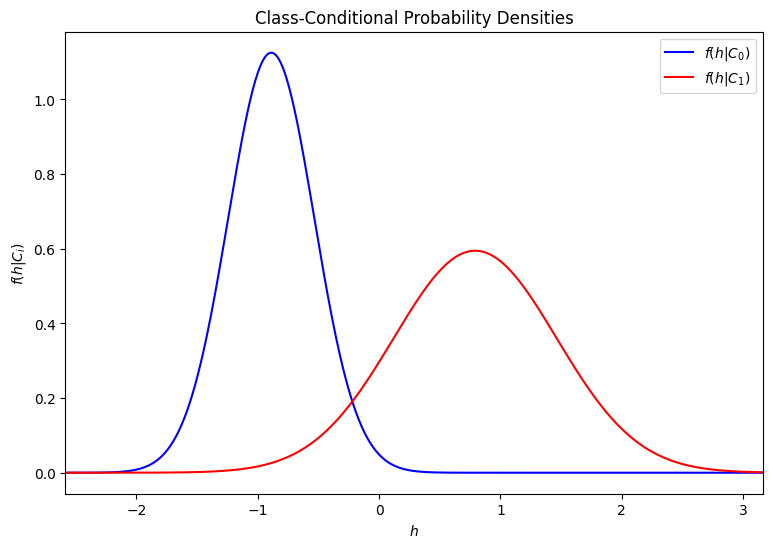

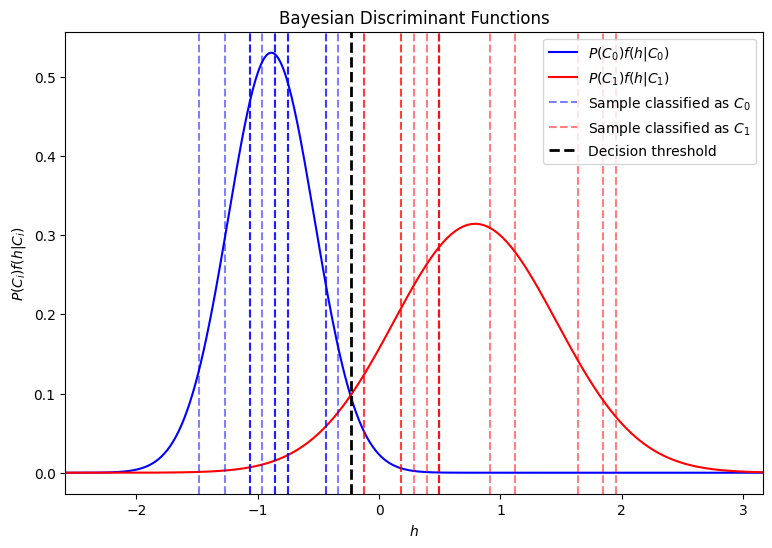

In [14]:
clf_bayes.plot(pred_bayes_1, pred_bayes_2)

#### Model Evaluation


Confusion matrix:
[[15  2]
 [ 0 13]]

Confusion matrix visualization:


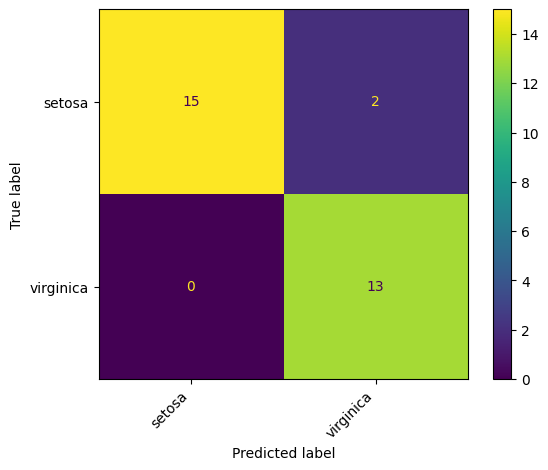

In [15]:
print('\nConfusion matrix:')
print(metrics.confusion_matrix(y_test, pred_bayes_2))

# Confusion matrix visualization
print('\nConfusion matrix visualization:')

metrics.ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_bayes_2,
    display_labels=class_names_
)

plt.xticks(rotation=45, ha='right')
plt.show()

In [16]:
print('\nClassification report:')
print(
    metrics.classification_report(
        y_test,
        pred_bayes_2,
        target_names=class_names_
    )
)

accuracy = metrics.accuracy_score(y_test, pred_bayes_2)
print(f'Accuracy: {accuracy:.4f}')


Classification report:
              precision    recall  f1-score   support

      setosa       1.00      0.88      0.94        17
   virginica       0.87      1.00      0.93        13

    accuracy                           0.93        30
   macro avg       0.93      0.94      0.93        30
weighted avg       0.94      0.93      0.93        30

Accuracy: 0.9333


## Implementando com scikit-learn
---

In [17]:
# Keep all three classes from the Iris dataset:
# Setosa (0), Versicolor (1), and Virginica (2)
X = iris.data
y = iris.target

# Select only two features:
# Sepal length (0) and sepal width (1)
X_ = X[:, [0, 1]]

In [18]:
# Split the dataset into training (70%) and test (30%) sets
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X_,
    y,
    test_size=0.3,
    random_state=42
)

In [19]:
# Create the standardization object
scaler = preprocessing.StandardScaler()

# Compute the mean and standard deviation using only the training set
scaler.fit(X_train)

# Standardize the training set
X_train_norm = scaler.transform(X_train)

# Standardize the test set using the training set statistics
X_test_norm = scaler.transform(X_test)

In [20]:
clf = naive_bayes.GaussianNB()

clf.fit(X_train_norm, y_train)

pred = clf.predict(X_test_norm)

#### Model Evaluation


Confusion matrix:
[[19  0  0]
 [ 0  7  6]
 [ 0  2 11]]

Confusion matrix visualization:


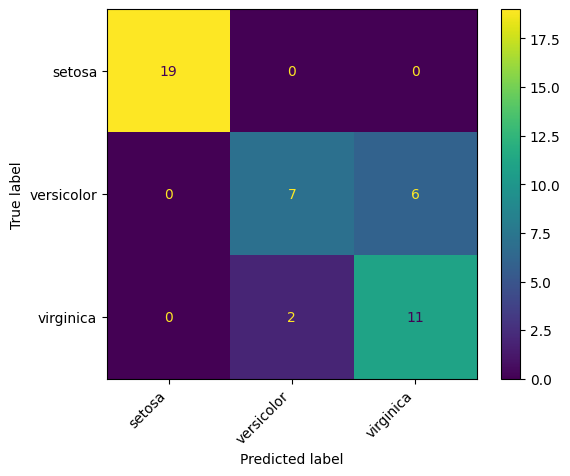

In [21]:
print('\nConfusion matrix:')
print(metrics.confusion_matrix(y_test, pred))

# Confusion matrix visualization
print('\nConfusion matrix visualization:')

metrics.ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred,
    display_labels=class_names
)

plt.xticks(rotation=45, ha='right')
plt.show()

In [22]:
print('\nClassification report:')
print(
    metrics.classification_report(
        y_test,
        pred,
        target_names=class_names
    )
)

accuracy = metrics.accuracy_score(y_test, pred)
print(f'Accuracy: {accuracy:.4f}')


Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       0.78      0.54      0.64        13
   virginica       0.65      0.85      0.73        13

    accuracy                           0.82        45
   macro avg       0.81      0.79      0.79        45
weighted avg       0.83      0.82      0.82        45

Accuracy: 0.8222


## License
---
Copyright (c) 2026 João Fernando Mari.

The Python source code and Jupyter Notebook are licensed under the MIT License.  
See the `LICENSE` file in the repository for details.

Third-party materials remain subject to the rights and licenses of their respective authors and owners.

## Bibliography
---

* GONZALEZ, R.C.; WOODS, R.E.; Digital Image Processing. 3rd Edition. Prentice Hall, 2008.
* DUDA, R.O.; HART, P.E.; STORK, D.G. Pattern Classification. 2nd Edition. Wiley-Interscience, 2001.
* COSTA, L. DA F.; CESAR-JR., R. M. Shape analysis and classification: theory and practice. CRC Press, 2000. Chapter 8.
* scikit-learn - User Guide.
    * https://scikit-learn.org/stable/user_guide.html